In [1]:
import itertools
import random
from dataclasses import dataclass, field
from typing import Literal, Optional

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.optimize import curve_fit

EXCLUDED_DEFENSE_SYSTEMS = {"Hok/Sok", "MazEF"}

In [2]:
plt.rcParams["axes.ymargin"] = 0
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["legend.edgecolor"] = "None"
plt.rcParams["legend.facecolor"] = "None"

In [3]:
@dataclass
class Plasmid:
    accession: str
    inc_groups: set[str] = field(default_factory=set)
    ds_type: set[str] = field(default_factory=set)
    ds_subtype: set[str] = field(default_factory=set)

In [4]:
def compute_iteration_curve(
    plasmids: list[Plasmid],
    ds_level: Literal["type", "subtype"],
    seed: int,
    max_n_plasmids: Optional[int] = None,
) -> list[int]:
    ds_list = [
        plasmid.ds_type if ds_level == "type" else plasmid.ds_subtype
        for plasmid in plasmids
    ]
    random.Random(seed).shuffle(ds_list)
    if max_n_plasmids and len(ds_list) > max_n_plasmids:
        ds_list = ds_list[:max_n_plasmids]
    sampled_ds = set()
    curve_i = []
    for ds in ds_list:
        sampled_ds.update(ds)
        curve_i.append(len(sampled_ds))
    return curve_i


def compute_rarefaction_curve(
    plasmids: list[Plasmid],
    inc_group: str,
    ds_level: Literal["type", "subtype"],
    n_iterations: int = 500,
    max_n_plasmids: Optional[int] = None,
) -> list[int]:
    curves = []
    plasmids = list(
        filter(
            lambda p: (inc_group == "All" or inc_group in p.inc_groups),
            plasmids,
        )
    )
    for i in range(n_iterations):
        curve_i = compute_iteration_curve(plasmids, ds_level, i, max_n_plasmids)
        curves.append(curve_i)
    return np.array(curves).mean(axis=0).tolist()

In [8]:
def heaps_law(n: int, kappa: float, gamma: float) -> float:
    return kappa * n**gamma


def compute_curve_gamma(curve: list[int]) -> float:
    popt, _ = curve_fit(heaps_law, range(1, len(curve) + 1), curve)
    return float(popt[1])

In [6]:
plasmid_dict = {}
for row in pl.read_excel(
    "data/plsdb_plasmid_inc.xlsx", infer_schema_length=0
).iter_rows(named=True):
    plasmid_accession = row["plasmid_seqid"]
    inc_group = row["rep"]
    if plasmid_accession not in plasmid_dict:
        plasmid_dict[plasmid_accession] = Plasmid(plasmid_accession)
    plasmid_dict[plasmid_accession].inc_groups.add(inc_group)

for row in pl.read_excel("data/plsdb_plasmid_defense.xlsx").iter_rows(named=True):
    plasmid_accession = row["plasmid_seqid"]
    if plasmid_accession in plasmid_dict:
        ds_type = str(row["type"]).strip()
        ds_subtype = str(row["subtype"]).strip()
        if ds_type in EXCLUDED_DEFENSE_SYSTEMS or ds_subtype in EXCLUDED_DEFENSE_SYSTEMS:
            continue
        plasmid_dict[plasmid_accession].ds_type.add(ds_type)
        plasmid_dict[plasmid_accession].ds_subtype.add(ds_subtype)

In [9]:
from collections import Counter
plasmids = list(plasmid_dict.values())

all_inc_groups = []
for p in plasmids:
    all_inc_groups.extend(p.inc_groups)

groups_to_plot = ["All"] + sorted(list(set(all_inc_groups)))

DEFAULT_COLOR = "#c5cad7"

INC_GROUP_COLORS = {
    "All": "black",
    "IncFIA": "#e69f00",
    "IncFIB": "#57b4e9",
    "IncFII": "#009e73",
    "IncL/M": "#f0e443",
    "IncK2/Z": "#0072b2",
    "IncX3": "#d55e00"
}

plasmid_curves_dict = {}
for p, t in itertools.product(
    groups_to_plot,
    ["type", "subtype"],
):
    curve = compute_rarefaction_curve(plasmids, p, t)
    if len(curve) > 1:
        gamma = compute_curve_gamma(curve)
    else:
        gamma = float("nan")
    plasmid_curves_dict[(p, t)] = (curve, gamma)

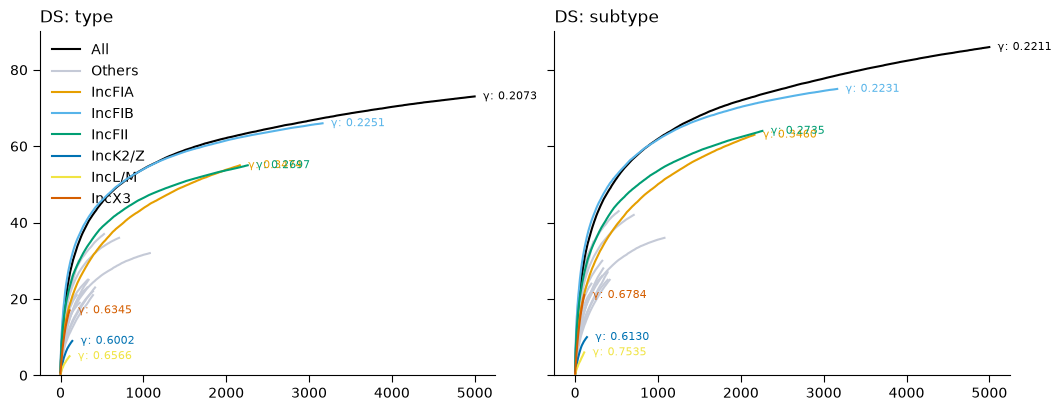

In [10]:
MAX_N_PLASMIDS = 5000

fig, ax = plt.subplots(
    ncols=2, figsize=(10.5, 4), sharex=True, sharey=True, constrained_layout=True
)
max_n_plasmids = 0
max_n_subsystems = 0

for i, group in enumerate(groups_to_plot):
    curve_1 = plasmid_curves_dict[(group, "type")][0]
    curve_2 = plasmid_curves_dict[(group, "subtype")][0]
    gamma_1 = plasmid_curves_dict[(group, "type")][1]
    gamma_2 = plasmid_curves_dict[(group, "subtype")][1]

    if MAX_N_PLASMIDS:
        curve_1 = curve_1[:MAX_N_PLASMIDS]
        curve_2 = curve_2[:MAX_N_PLASMIDS]

    if group in INC_GROUP_COLORS:
        color = INC_GROUP_COLORS[group]
        label = group
        zorder = 10
    elif group == "All":
        color = "black"
        label = "All"
        zorder = 100
    else:
        color = DEFAULT_COLOR
        label = "Others"
        zorder = 1

    if len(curve_1) > 0:
        if label == "Others":
            if "Others" not in ax[0].get_legend_handles_labels()[1]:
                 ax[0].plot(curve_1, label=label, c=color, zorder=zorder)
            else:
                 ax[0].plot(curve_1, c=color, zorder=zorder)
        else:
            ax[0].plot(curve_1, label=label, c=color, zorder=zorder)
            
        if len(curve_1) > max_n_plasmids:
            max_n_plasmids = len(curve_1)
        
        if not np.isnan(gamma_1) and label != "Others":
             ax[0].text(
                len(curve_1) + 100,
                curve_1[-1],
                f"γ: {gamma_1:.4f}",
                ha="left",
                va="center",
                fontsize=8,
                color=color,
            )
    if len(curve_2) > 0:
        ax[1].plot(curve_2, c=color, zorder=zorder)
        if max(curve_2) > max_n_subsystems:
            max_n_subsystems = max(curve_2)
        if not np.isnan(gamma_2) and label != "Others":
            ax[1].text(
                len(curve_2) + 100,
                curve_2[-1],
                f"γ: {gamma_2:.4f}",
                ha="left",
                va="center",
                fontsize=8,
                color=color,
            )
x_padding = max_n_plasmids * 0.05
y_padding = max_n_subsystems * 0.05
ax[0].set_title("DS: type", loc="left")
ax[1].set_title("DS: subtype", loc="left")
ax[0].set_ylim(0, max_n_subsystems + y_padding)
ax[0].set_xlim(-x_padding, max_n_plasmids + x_padding)
ax[0].legend(loc="upper left")
fig.savefig("plots/figS09_A.pdf", dpi=200)

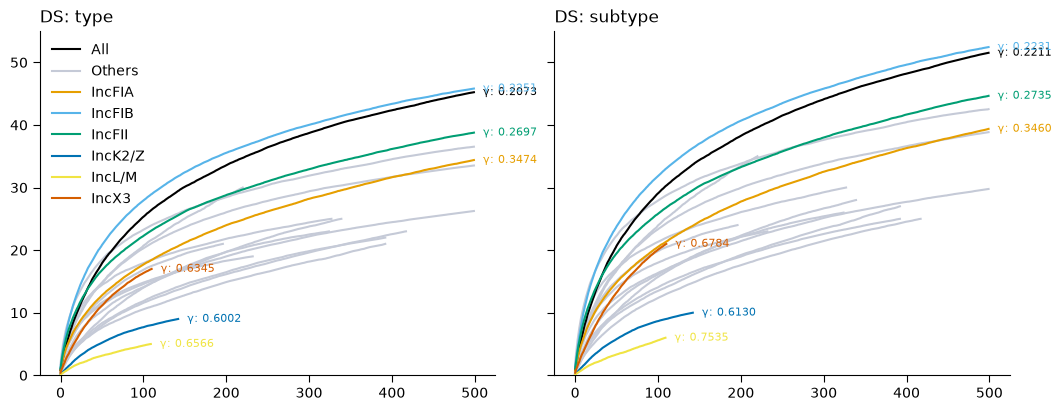

In [11]:
MAX_N_PLASMIDS = 500

fig, ax = plt.subplots(
    ncols=2, figsize=(10.5, 4), sharex=True, sharey=True, constrained_layout=True
)
max_n_plasmids = 0
max_n_subsystems = 0

for i, group in enumerate(groups_to_plot):
    curve_1 = plasmid_curves_dict[(group, "type")][0]
    curve_2 = plasmid_curves_dict[(group, "subtype")][0]
    gamma_1 = plasmid_curves_dict[(group, "type")][1]
    gamma_2 = plasmid_curves_dict[(group, "subtype")][1]
    
    if MAX_N_PLASMIDS:
        curve_1 = curve_1[:MAX_N_PLASMIDS]
        curve_2 = curve_2[:MAX_N_PLASMIDS]

    if group in INC_GROUP_COLORS:
        color = INC_GROUP_COLORS[group]
        label = group
        zorder = 10
    elif group == "All":
        color = "black"
        label = "All"
        zorder = 100
    else:
        color = DEFAULT_COLOR
        label = "Others"
        zorder = 1

    if len(curve_1) > 0:
        
        if label == "Others":
            if "Others" not in ax[0].get_legend_handles_labels()[1]:
                 ax[0].plot(curve_1, label=label, c=color, zorder=zorder)
            else:
                 ax[0].plot(curve_1, c=color, zorder=zorder)
        else:
            ax[0].plot(curve_1, label=label, c=color, zorder=zorder)
            
        if len(curve_1) > max_n_plasmids:
            max_n_plasmids = len(curve_1)
        
        if not np.isnan(gamma_1) and label != "Others":
             ax[0].text(
                len(curve_1) + 10,
                curve_1[-1],
                f"γ: {gamma_1:.4f}",
                ha="left",
                va="center",
                fontsize=8,
                color=color,
            )
    if len(curve_2) > 0:
        ax[1].plot(curve_2, c=color, zorder=zorder)
        if max(curve_2) > max_n_subsystems:
            max_n_subsystems = max(curve_2)
        if not np.isnan(gamma_2) and label != "Others":
            ax[1].text(
                len(curve_2) + 10,
                curve_2[-1],
                f"γ: {gamma_2:.4f}",
                ha="left",
                va="center",
                fontsize=8,
                color=color,
            )
x_padding = max_n_plasmids * 0.05
y_padding = max_n_subsystems * 0.05
ax[0].set_title("DS: type", loc="left")
ax[1].set_title("DS: subtype", loc="left")
ax[0].set_ylim(0, max_n_subsystems + y_padding)
ax[0].set_xlim(-x_padding, max_n_plasmids + x_padding)
ax[0].legend(loc="upper left")
fig.savefig("plots/figS09_B.pdf", dpi=200)